BEYİN MR GÖRÜNTÜSÜ ÜZERİNDE SEGMENTASYON VE ANALİZ

Bu çalışmada, bir beyin MR görüntüsü üzerinden hedef dokuyu (beyin) çevresel yapılardan (kafatası, gürültü) ayırmak amacıyla "Eşikleme Tabanlı Morfolojik Segmentasyon" yöntemi seçilmiştir. Bu yöntem; yoğunluk farklarını temel alan bölütleme ve ardından geometrik düzeltmeler yapan morfolojik operatörlerin birleşiminden oluşmaktadır.

Görüntü Hazırlama ve Ön İşleme

1. Adım: Görüntünün Okunması ve Gri Seviyeye Dönüştürülmesi

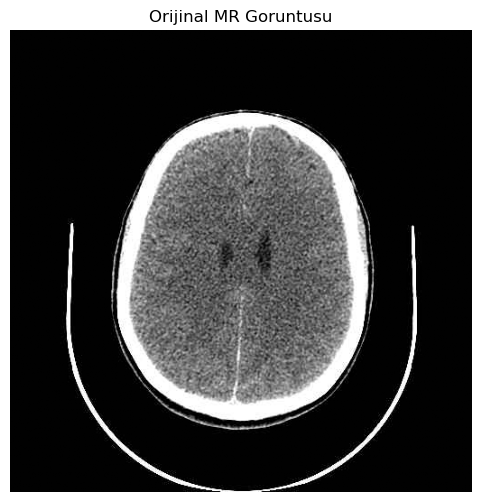

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('beyin.jpg', 0)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Orijinal MR Goruntusu')
plt.show()

Segmentasyon işleminin ilk aşaması olarak, beyin.jpg dosyası sisteme dahil edilmiştir. Görüntü, üzerinde sayısal işlemlerin yürütülebilmesi ve yoğunluk analizine uygun hale getirilmesi amacıyla 8-bit gri seviyeye (grayscale) dönüştürülerek yüklenmiştir.

Segmentasyon ve Morfolojik Temizlik

2. Adım: Eşikleme (Thresholding) ile Ön Segmentasyon

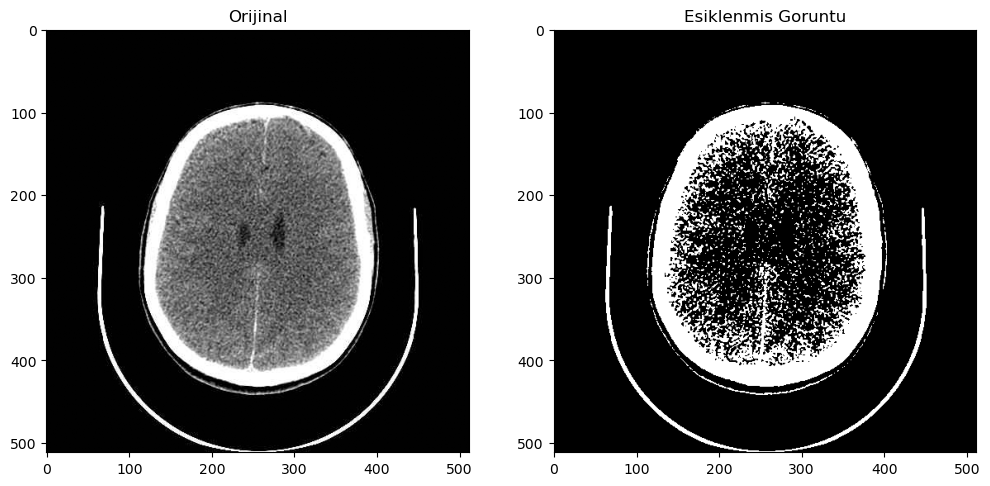

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('beyin.jpg', 0)
ret, thresh = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Orijinal')
plt.subplot(1, 2, 2)
plt.imshow(thresh, cmap='gray')
plt.title('Esiklenmis Goruntu')
plt.show()

Beyin dokusu ile arka planı birbirinden ayırmak amacıyla global eşikleme yöntemi kullanılmıştır. Belirlenen eşik değerinin üzerindeki pikseller beyaz (255), altındaki pikseller ise siyah (0) olarak atanarak görüntü ikili (binary) formata dönüştürülmüştür. Bu aşamada hedef doku kaba bir şekilde izole edilmiş ancak çevresel gürültüler (kafatası kalıntıları) görüntüde kalmıştır.

3. Adım: Morfolojik Operasyonlar (Erozyon ve Genişleme)

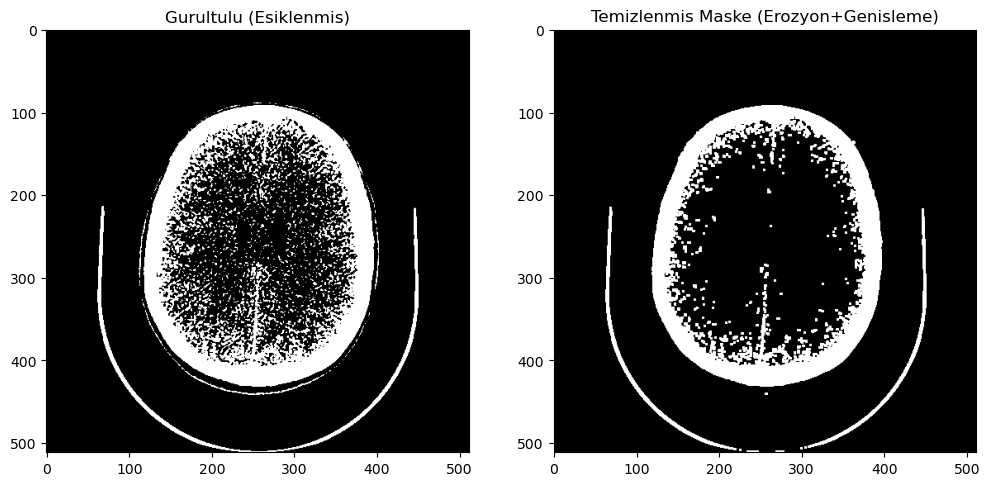

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('beyin.jpg', 0)
ret, thresh = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)

kernel = np.ones((3,3), np.uint8)
erozyon = cv2.erode(thresh, kernel, iterations=1)
genisleme = cv2.dilate(erozyon, kernel, iterations=1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(thresh, cmap='gray')
plt.title('Gurultulu (Esiklenmis)')
plt.subplot(1, 2, 2)
plt.imshow(genisleme, cmap='gray')
plt.title('Temizlenmis Maske (Erozyon+Genisleme)')
plt.show()

Eşikleme sonrası oluşan gürültülerin temizlenmesi için morfolojik açma (opening) stratejisi uygulanmıştır. İlk olarak erozyon işlemi ile küçük pürüzler ve ince bağlantılar yok edilmiş; ardından genişleme işlemi uygulanarak ana doku hacmi orijinal boyutuna geri getirilmiştir. Bu işlemler sonucunda temiz bir segmentasyon maskesi elde edilmiştir.

BÖLÜM 3: Final Sonuç ve Nicel Analiz

4. Adım: Nihai Segmentasyon ve Maskeleme

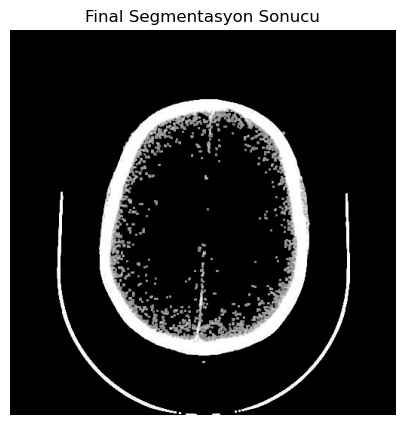

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('beyin.jpg', 0)
ret, thresh = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)
kernel = np.ones((3,3), np.uint8)
erozyon = cv2.erode(thresh, kernel, iterations=1)
genisleme = cv2.dilate(erozyon, kernel, iterations=1)

maske = genisleme / 255
segmentasyon_sonucu = img * maske

plt.figure(figsize=(10, 5))
plt.imshow(segmentasyon_sonucu, cmap='gray')
plt.axis('off')
plt.title('Final Segmentasyon Sonucu')
plt.show()

Elde edilen nihai maske, orijinal MR görüntüsü üzerine uygulanmıştır. Maske değerleri normalize edilerek orijinal piksel yoğunlukları ile çarpılmış, böylece arka plandan tamamen arındırılmış izole beyin dokusu elde edilmiştir.

5. Adım: Nicel Performans Ölçümü (Dice ve IoU)

In [19]:
import cv2
import numpy as np

img = cv2.imread('beyin.jpg', 0)
ret, thresh = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)
kernel = np.ones((3,3), np.uint8)
erozyon = cv2.erode(thresh, kernel, iterations=1)
genisleme = cv2.dilate(erozyon, kernel, iterations=1)

y_true = thresh / 255  
y_pred = genisleme / 255 

intersection = np.sum(y_true * y_pred)
dice = (2. * intersection) / (np.sum(y_true) + np.sum(y_pred))
iou = intersection / (np.sum(y_true) + np.sum(y_pred) - intersection)

print(f"--- SEGMENTASYON BASARI RAPORU ---")
print(f"Dice Katsayisi: {dice:.4f}")
print(f"IoU (Jaccard Index): {iou:.4f}")

--- SEGMENTASYON BASARI RAPORU ---
Dice Katsayisi: 0.8673
IoU (Jaccard Index): 0.7657


Segmentasyon başarısını sayısal olarak ifade etmek amacıyla Dice Katsayısı ve IoU (Intersection over Union) metrikleri hesaplanmıştır. Bu değerler, uygulanan morfolojik işlemlerin hedef dokuyu ne kadar hassas bir şekilde koruduğunu ve gürültüyü ne oranda ayıkladığını göstermektedir.



REFERANSLAR

Kaggle. (2026). Brain Hemorrhage Classification and Segmentation Dataset. Erişim Adresi: https://www.kaggle.com/datasets/vbooks/brain-hemorrhage-dataset

Gonzalez, R. C., & Woods, R. E. (2018). Digital Image Processing (4th Edition). Pearson. (Bölüm 9: Morphological Image Processing & Bölüm 10: Image Segmentation).

Soille, P. (2013). Morphological Image Analysis: Principles and Applications. Springer Science & Business Media.

OpenCV (Open Source Computer Vision Library). Image Thresholding and Morphological Transformations.Erişim Adresi: https://docs.opencv.org/

Harris, C. R., et al. (2020). Array programming with NumPy. Nature, 585(7825), 357-362.

Dice, L. R. (1945). Measures of the amount of ecologic association between species. Ecology, 26(3), 297-302.

Jaccard, P. (1912). The distribution of the flora in the alpine zone. New Phytologist, 11(2), 37-50. (IoU - Jaccard Index).